# 0 Imports

In [2]:
import sys
from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "src"))
from model.dataset import collect_samples

/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:
pd.set_option("display.width", 200, "display.max_columns", 60)

In [4]:
GASTRONORM = Path('/home/ethantu/workspace/good-vibrations/experiments/31_07_2026_gastronorm_exp1/samples')
BREADBOX = Path('/home/ethantu/workspace/good-vibrations/experiments/experiment-25/samples')

# 1 Create DF

In [5]:
def parse_avg_com(v):
    """GASTRONORM stores avg_com as a numpy repr string ('[722.8 726.5]'); BREADBOX
    stores a real list. Return a list of floats either way."""
    if isinstance(v, str): return [float(x) for x in v.strip("[]").split()]
    return v


def n_coms(coms):
    """GASTRONORM: list of per-object entries. BREADBOX: dict name -> com. Either way
    the object count is just the length."""
    return len(coms) if coms else 0


def build_df(sample_dir):
    samples = collect_samples(sample_dir, verbose=1)
    print(f"{len(samples)} complete samples")

    SCALAR_KEYS = [
        "sample_id", "position_id", "speaker", "box", "n_objects", "layout",
        "is_empty_box", "laser_idx", "min_freq", "max_freq", "fps", "power",
        "n_rows", "n_cols", "use_PC",
    ]

    rows = []
    for sample_dir, meta in samples:
        row = {k: meta.get(k) for k in SCALAR_KEYS}
        row["dir"] = sample_dir
        row["avg_com"] = parse_avg_com(meta.get("avg_com"))
        row["n_coms"] = n_coms(meta.get("coms"))
        rows.append(row)

    df = pd.DataFrame(rows)
    df["sample_id_int"] = df["sample_id"].astype(int)
    df = df.sort_values("sample_id_int").reset_index(drop=True)
    return df

gastronorm_df = build_df(GASTRONORM)
breadbox_df = build_df(BREADBOX)

collecting samples: 100%|██████████| 3008/3008 [00:01<00:00, 2537.11it/s]


Found 3007 complete samples (1 skipped)
missing 'vibration/04_fft.npz': ['000009']
3007 complete samples


collecting samples: 100%|██████████| 1024/1024 [00:00<00:00, 3083.02it/s]

Found 1024 complete samples (0 skipped)
1024 complete samples


In [6]:
gastronorm_df

,sample_id,position_id,speaker,box,n_objects,layout,is_empty_box,laser_idx,min_freq,max_freq,fps,power,n_rows,n_cols,use_PC,dir,avg_com,n_coms,sample_id_int
0,000010,2,2,gastronorm,0,empty-box,True,55,50,1000,2500,440.9,10,10,False,/home/ethantu/workspace/good-vibrations/experi...,"[-1.0, -1.0]",1,10
1,000011,2,3,gastronorm,0,empty-box,True,55,50,1000,2500,440.9,10,10,False,/home/ethantu/workspace/good-vibrations/experi...,"[-1.0, -1.0]",1,11
2,000012,2,4,gastronorm,0,empty-box,True,55,50,1000,2500,440.9,10,10,False,/home/ethantu/workspace/good-vibrations/experi...,"[-1.0, -1.0]",1,12
3,000013,2,5,gastronorm,0,empty-box,True,55,50,1000,2500,440.9,10,10,False,/home/ethantu/workspace/good-vibrations/experi...,"[-1.0, -1.0]",1,13
4,000014,2,6,gastronorm,0,empty-box,True,55,50,1000,2500,440.9,10,10,False,/home/ethantu/workspace/good-vibrations/experi...,"[-1.0, -1.0]",1,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3002,003012,377,4,gastronorm,2,y-shift,False,55,50,1000,2500,440.9,10,10,True,/home/ethantu/workspace/good-vibrations/experi...,"[552.48630389, 662.82215262]",2,3012
3003,003013,377,5,gastronorm,2,y-shift,False,55,50,1000,2500,440.9,10,10,True,/home/ethantu/workspace/good-vibrations/experi...,"[552.48630389, 662.82215262]",2,3013
3004,003014,377,6,gastronorm,2,y-shift,False,55,50,1000,2500,440.9,10,10,True,/home/ethantu/workspace/good-vibrations/experi...,"[552.48630389, 662.82215262]",2,3014
3005,003015,377,7,gastronorm,2,y-shift,False,55,50,1000,2500,440.9,10,10,True,/home/ethantu/workspace/good-vibrations/experi...,"[552.48630389, 662.82215262]",2,3015


In [7]:
breadbox_df

,sample_id,position_id,speaker,box,n_objects,layout,is_empty_box,laser_idx,min_freq,max_freq,fps,power,n_rows,n_cols,use_PC,dir,avg_com,n_coms,sample_id_int
0,000001,None,1,metal,0,empty-box,True,None,50,1000,2500,None,None,None,None,/home/ethantu/workspace/good-vibrations/experi...,"[-1.0, -1.0]",1,1
1,000002,None,2,metal,0,empty-box,True,None,50,1000,2500,None,None,None,None,/home/ethantu/workspace/good-vibrations/experi...,"[-1.0, -1.0]",1,2
2,000003,None,3,metal,0,empty-box,True,None,50,1000,2500,None,None,None,None,/home/ethantu/workspace/good-vibrations/experi...,"[-1.0, -1.0]",1,3
3,000004,None,4,metal,0,empty-box,True,None,50,1000,2500,None,None,None,None,/home/ethantu/workspace/good-vibrations/experi...,"[-1.0, -1.0]",1,4
4,000005,None,5,metal,0,empty-box,True,None,50,1000,2500,None,None,None,None,/home/ethantu/workspace/good-vibrations/experi...,"[-1.0, -1.0]",1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1019,001020,None,4,metal,1,green-cube,False,None,50,1000,2500,None,None,None,None,/home/ethantu/workspace/good-vibrations/experi...,"[153.57229398663696, 503.4963919821826]",1,1020
1020,001021,None,5,metal,1,green-cube,False,None,50,1000,2500,None,None,None,None,/home/ethantu/workspace/good-vibrations/experi...,"[153.57229398663696, 503.4963919821826]",1,1021
1021,001022,None,6,metal,1,green-cube,False,None,50,1000,2500,None,None,None,None,/home/ethantu/workspace/good-vibrations/experi...,"[153.57229398663696, 503.4963919821826]",1,1022
1022,001023,None,7,metal,1,green-cube,False,None,50,1000,2500,None,None,None,None,/home/ethantu/workspace/good-vibrations/experi...,"[153.57229398663696, 503.4963919821826]",1,1023


# 2 Box coverage

Gastronorm: 3007 masks, native 1110x1337, coverage max=0.077 mean=0.014
Breadbox: 1024 masks, native 309x679, coverage max=0.422 mean=0.071


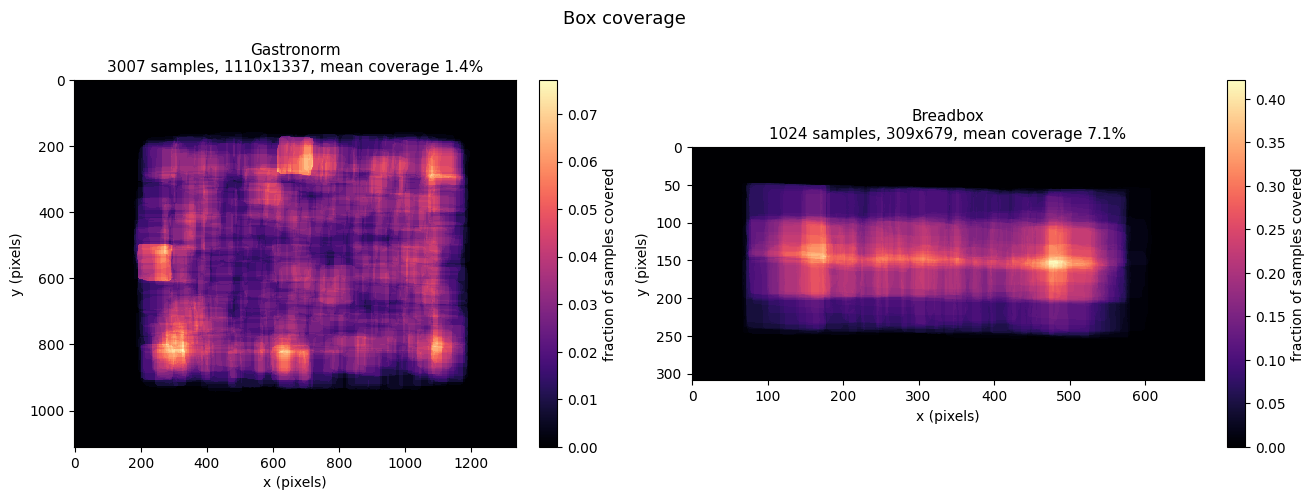

In [8]:
import matplotlib.pyplot as plt
import numpy as np


def box_coverage(sample_dirs, smask_name="image/03_smask.npy"):
    """Fraction of samples in which each pixel falls inside an object mask.

    Returns (coverage, n, (H, W)) where coverage is the per-pixel mean over every
    sample's full-resolution smask and (H, W) is that native resolution.
    """
    total, n, shape = None, 0, None
    for sample_dir in sample_dirs:
        path = sample_dir / smask_name
        if not path.exists(): continue
        mask = np.load(path).astype(np.float32)
        if total is None: total, shape = np.zeros_like(mask), mask.shape
        total += mask
        n += 1
    return total / max(n, 1), n, shape


def plot_box_coverage(datasets, share_scale=True):
    """Side-by-side coverage heatmaps. Each panel keeps its own native resolution
    (the two boxes differ in size and aspect ratio).

    share_scale=True puts both on one color scale, so the colors are comparable but
    the lower-coverage panel looks dim; False scales each to its own max, which shows
    each layout's structure at the cost of cross-panel comparability.
    """
    vmax = max(c.max() for _, c, _, _ in datasets) if share_scale else None
    fig, axes = plt.subplots(1, len(datasets), figsize=(7 * len(datasets), 5))
    axes = np.atleast_1d(axes)

    for ax, (label, coverage, n, (h, w)) in zip(axes, datasets):
        top = vmax if share_scale else coverage.max()
        im = ax.imshow(coverage, cmap="magma", vmin=0, vmax=top, interpolation="nearest")
        ax.set_title(f"{label}\n{n} samples, {h}x{w}, mean coverage {coverage.mean():.1%}", fontsize=11)
        ax.set_xlabel("x (pixels)")
        ax.set_ylabel("y (pixels)")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="fraction of samples covered")

    fig.suptitle(f"Box coverage", fontsize=13)
    fig.tight_layout()
    plt.show()


datasets = []
for label, df in (("Gastronorm", gastronorm_df), ("Breadbox", breadbox_df)):
    coverage, n, shape = box_coverage(df["dir"])
    print(f"{label}: {n} masks, native {shape[0]}x{shape[1]}, "
          f"coverage max={coverage.max():.3f} mean={coverage.mean():.3f}")
    datasets.append((label, coverage, n, shape))

plot_box_coverage(datasets, share_scale=False)

* On average, a single sample in the gastronorm covers 1.4% of pixels in the frame while a single sample in the breadbox covers 7.1% of pixels. 
* The gastronorm signal is 5x more sparse.
* This is mainly driven by frame size since the gastronorm frame is 7.1x bigger than the breadbox.

In [9]:
def _as_list(v):
    """None stays None (meaning 'all'); a scalar becomes a 1-element list."""
    if v is None: return None
    return list(v) if isinstance(v, (list, tuple, set, np.ndarray, pd.Series)) else [v]


def _fmt(v):
    """Compact display for a filter value: unwrap 1-element lists, elide long ones."""
    vals = _as_list(v)
    if vals is None: return "all"
    if len(vals) == 1: return str(vals[0])
    if len(vals) > 4: return f"{len(vals)} values [{vals[0]}...{vals[-1]}]"
    return "[" + ", ".join(str(x) for x in vals) + "]"


def filter_df(df, sample_id=None, speaker=None, position_id=None, n_objects=None, verbose=True):
    """Filter a sample dataframe.

    Every argument takes a scalar, a list, or None ('all'). sample_id overrides the
    other filters when given. Returns (filtered_df, subtitle) where subtitle spells
    out every filter -- including the ones left as 'all' -- so a plot can always show
    exactly what it is displaying.

    Columns that exist but are entirely unpopulated for a dataset (e.g. position_id
    in BREADBOX) are skipped with a note rather than silently matching nothing.
    """
    applied = {}
    if sample_id is not None:
        wanted = {str(s).zfill(6) for s in _as_list(sample_id)}
        out = df[df["sample_id"].astype(str).str.zfill(6).isin(wanted)]
        applied["sample_id"] = _fmt(sample_id)
    else:
        out = df
        for col, val in (("speaker", speaker), ("position_id", position_id),
                          ("n_objects", n_objects)):
            vals = _as_list(val)
            if vals is None:
                applied[col] = "all"
                continue
            if col not in out.columns or out[col].isna().all():
                if verbose: print(f"  (skipping {col} filter: not populated in this dataset)")
                applied[col] = "n/a"
                continue
            out = out[out[col].isin(vals)]
            applied[col] = _fmt(val)

    subtitle = " | ".join(f"{k}={v}" for k, v in applied.items())
    return out, f"{subtitle}  ->  {len(out)} samples"


def load_fft_magnitudes(rows, laser=None, xy_channel=None, fft_name="vibration/04_fft.npz"):
    """Stack |FFT| for the given rows, keeping only the requested lasers/channels.

    Each sample's fft is (1, L, F, C). Returns (stack, freqs) where stack is
    (n_kept, F) -- one magnitude spectrum per (sample, laser, channel) kept.
    """
    lasers, channels, spectra, freqs = _as_list(laser), _as_list(xy_channel), [], None
    for sample_dir in rows["dir"]:
        path = sample_dir / fft_name
        if not path.exists(): continue
        with np.load(path) as z:
            fft, f = z["fft"], z["freqs"]
        if freqs is None: freqs = f
        mag = np.abs(fft[0])                                  # (L, F, C)
        li = lasers if lasers is not None else range(mag.shape[0])
        ci = channels if channels is not None else range(mag.shape[2])
        for l in li:
            for c in ci:
                spectra.append(mag[l, :, c])
    return (np.stack(spectra) if spectra else np.empty((0, 0))), freqs


# assigned in fixed order, never cycled -- an 9th series folds into "other"
SERIES_COLORS = ["#4b6bfb", "#d9730d", "#0f9960", "#9c27b0", "#00838f", "#c2185b",
                 "#5d4037", "#455a64"]


def plot_fft_by(df, color_by, label="", values=None, ax=None, title=None,
                 show_std=False, **kwargs):
    """Overlay one mean spectrum per distinct value of color_by on a single axis.

    color_by names any filter that plot_fft_magnitude accepts ('n_objects',
    'speaker', 'position_id', 'laser', 'xy_channel'). values pins which ones to
    draw and in what order; by default every value present in df is used, sorted.
    Remaining kwargs pass straight through to plot_fft_magnitude.

    show_std defaults to False here (unlike plot_fft_magnitude): several overlaid
    std bands muddy each other. Set it True to draw a band per series anyway.
    """
    if values is None:
        if color_by in ("laser", "xy_channel"):
            raise ValueError(f"color_by={color_by!r} needs an explicit values=[...]")
        values = sorted(v for v in df[color_by].dropna().unique())

    own_ax = ax is None
    if own_ax: _, ax = plt.subplots(figsize=(14, 4.5))

    pinned = {k: v for k, v in kwargs.items()
              if k in ("laser", "xy_channel", "speaker", "position_id", "n_objects") and v is not None}
    desc = " | ".join(f"{k}={_fmt(v)}" for k, v in pinned.items())
    auto_title = f"{label} FFT magnitude\n{desc} | colored by {color_by}"

    for v, color in zip(values, SERIES_COLORS):
        plot_fft_magnitude(df, label, ax=ax, color=color, series_label=f"{color_by}={v}",
                           show_std=show_std, title=title if title is not None else auto_title,
                           **{**kwargs, color_by: v})

    if own_ax:
        plt.tight_layout()
        plt.show()


def plot_fft_magnitude(df, label="", sample_id=None, laser=None, xy_channel=None,
                        speaker=None, position_id=None, n_objects=None,
                        fft_name="vibration/04_fft.npz", normalize_std=False,
                        logy=False, ax=None, xlim=None, ylim=None,
                        color="#4b6bfb", series_label=None, show_std=True, title=None):
    """Plot |FFT| for a slice of a dataframe.

    laser / xy_channel / speaker / position_id / n_objects each take a scalar, a
    list, or None. None means 'all of them', and everything left unpinned is
    aggregated: the mean is drawn as a line with a +/-1 std band. Pass sample_id
    (scalar or list) to pick samples directly, overriding the other row filters.

    normalize_std divides each spectrum by its own std before averaging, so every
    spectrum has std 1 and contributes equally regardless of absolute signal
    strength. Off by default, which keeps the raw |FFT| units.

    Pass color / series_label to draw several slices onto one shared ax (set
    show_std=False to keep an overlay readable), and title to override the
    auto-generated two-line title.
    """
    rows, subtitle = filter_df(df, sample_id, speaker, position_id, n_objects)
    subtitle = f"laser={_fmt(laser)} | xy={_fmt(xy_channel)} | {subtitle}"
    if normalize_std: subtitle += " | normalized (std=1)"
    if rows.empty:
        print(f"{label}: no samples matched -- {subtitle}"); return

    stack, freqs = load_fft_magnitudes(rows, laser, xy_channel, fft_name)
    if stack.size == 0:
        print(f"{label}: matched {len(rows)} samples but none had {fft_name}"); return

    if normalize_std:
        # per-spectrum, so a loud sample can't dominate the mean
        stack = stack / (stack.std(axis=1, keepdims=True) + 1e-12)
    mean, std = stack.mean(axis=0), stack.std(axis=0)

    own_ax = ax is None
    if own_ax: _, ax = plt.subplots(figsize=(14, 4.5))

    ax.plot(freqs, mean, lw=0.9, color=color,
            label=series_label or f"mean of {len(stack)} spectra")
    if show_std and len(stack) > 1:
        ax.fill_between(freqs, np.maximum(mean - std, 0), mean + std, color=color,
                        alpha=0.2, lw=0, label=None if series_label else "+/-1 std")
    ax.set_title(title if title is not None else f"{label} FFT magnitude\n{subtitle}", fontsize=11)
    ax.set_xlabel("frequency (Hz)")
    ax.set_ylabel("|FFT| / std" if normalize_std else "|FFT|")
    ax.set_xlim(freqs[0], freqs[-1])
    if logy: ax.set_yscale("log")
    else: ax.set_ylim(bottom=0)
    ax.legend(loc="upper right", fontsize=9, frameon=False)
    ax.grid(color="0.85", lw=0.6)
    ax.set_axisbelow(True)

    if xlim is not None: ax.set_xlim(*xlim)
    if ylim is not None: ax.set_ylim(*ylim)

    if own_ax:
        plt.tight_layout()
        plt.show()
    return stack, freqs

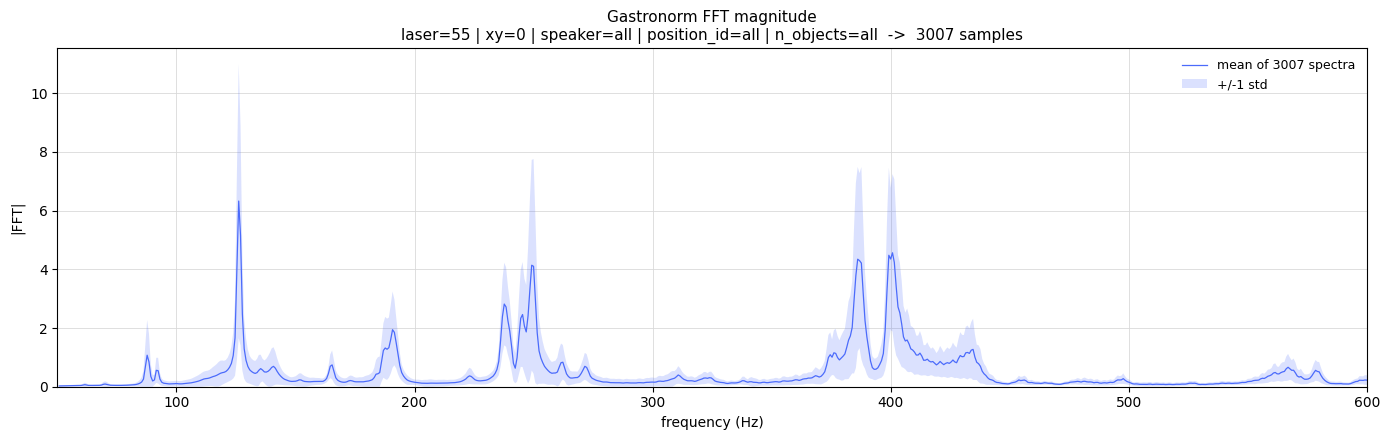

(array([[0.03928523, 0.04189707, 0.03832465, ..., 0.01093872, 0.01059272,
         0.00425575],
        [0.0244686 , 0.02556035, 0.0068524 , ..., 0.00747943, 0.01951054,
         0.01317993],
        [0.0017466 , 0.01933251, 0.01299639, ..., 0.01092073, 0.01486597,
         0.02869302],
        ...,
        [0.04484722, 0.03332506, 0.01023821, ..., 0.02071666, 0.02801407,
         0.02631368],
        [0.05777848, 0.01804309, 0.01862994, ..., 0.02164697, 0.01078852,
         0.01328202],
        [0.01237771, 0.06369005, 0.02901636, ..., 0.01954958, 0.02142308,
         0.02395964]], dtype=float32),
 array([  50.76923077,   51.53846154,   52.30769231, ...,  998.46153846,
         999.23076923, 1000.        ]))

In [10]:
plot_fft_magnitude(gastronorm_df, "Gastronorm", laser=55, xy_channel=0, xlim=(50, 600))

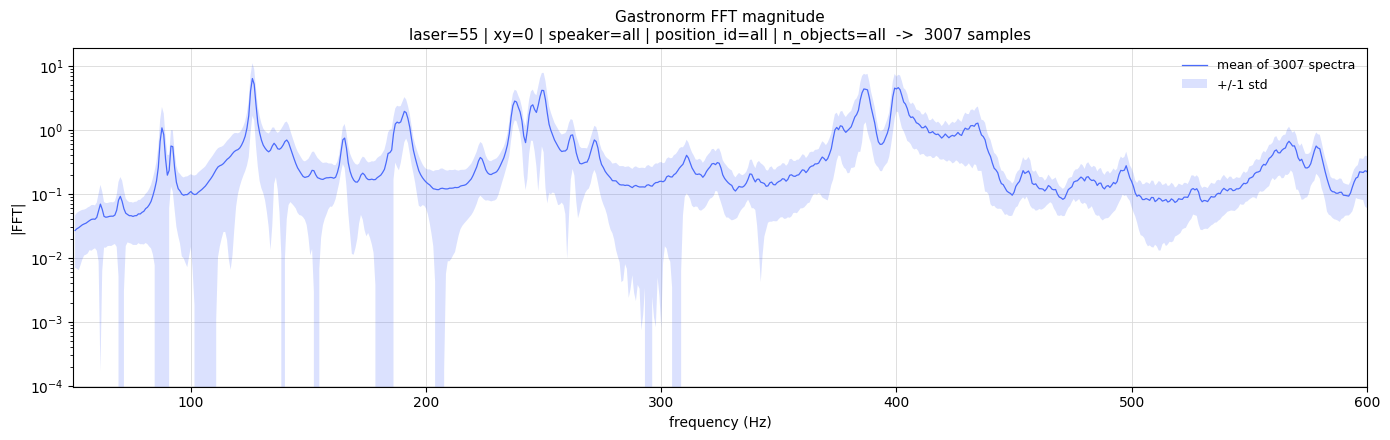

(array([[0.03928523, 0.04189707, 0.03832465, ..., 0.01093872, 0.01059272,
         0.00425575],
        [0.0244686 , 0.02556035, 0.0068524 , ..., 0.00747943, 0.01951054,
         0.01317993],
        [0.0017466 , 0.01933251, 0.01299639, ..., 0.01092073, 0.01486597,
         0.02869302],
        ...,
        [0.04484722, 0.03332506, 0.01023821, ..., 0.02071666, 0.02801407,
         0.02631368],
        [0.05777848, 0.01804309, 0.01862994, ..., 0.02164697, 0.01078852,
         0.01328202],
        [0.01237771, 0.06369005, 0.02901636, ..., 0.01954958, 0.02142308,
         0.02395964]], dtype=float32),
 array([  50.76923077,   51.53846154,   52.30769231, ...,  998.46153846,
         999.23076923, 1000.        ]))

In [11]:
plot_fft_magnitude(gastronorm_df, "Gastronorm", laser=55, xy_channel=0, logy=True, xlim=(50, 600))

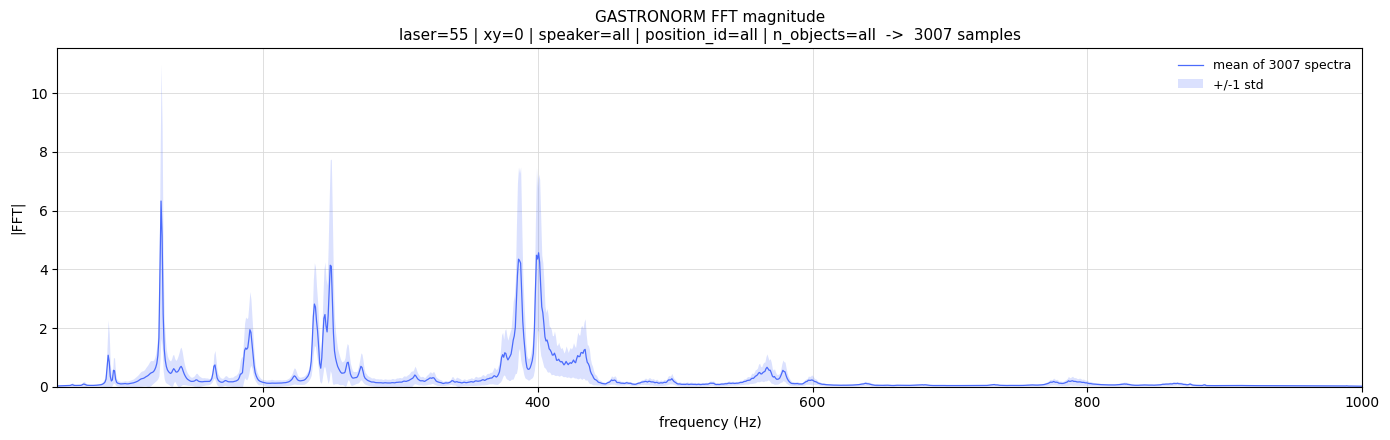

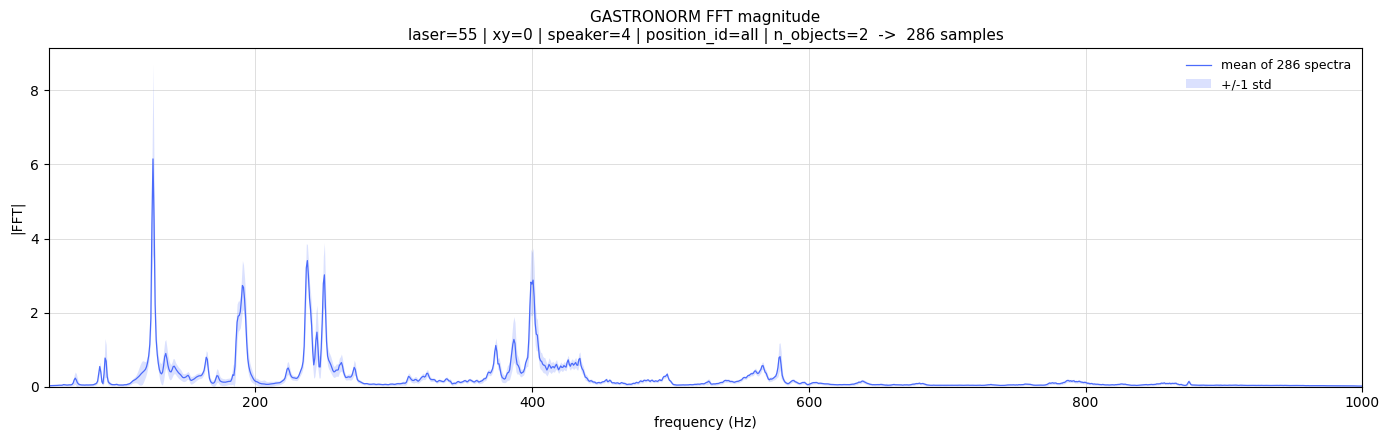

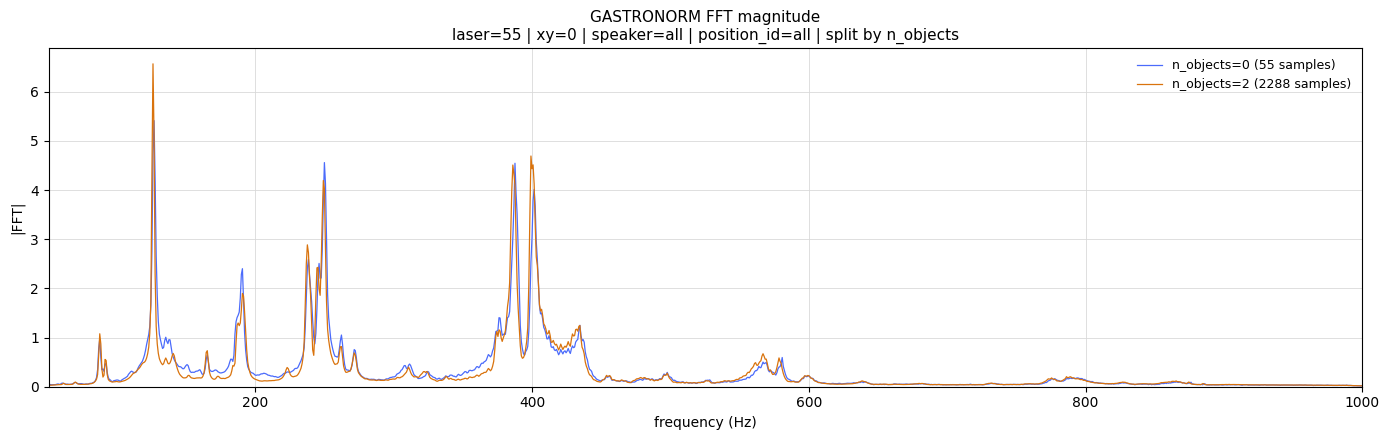

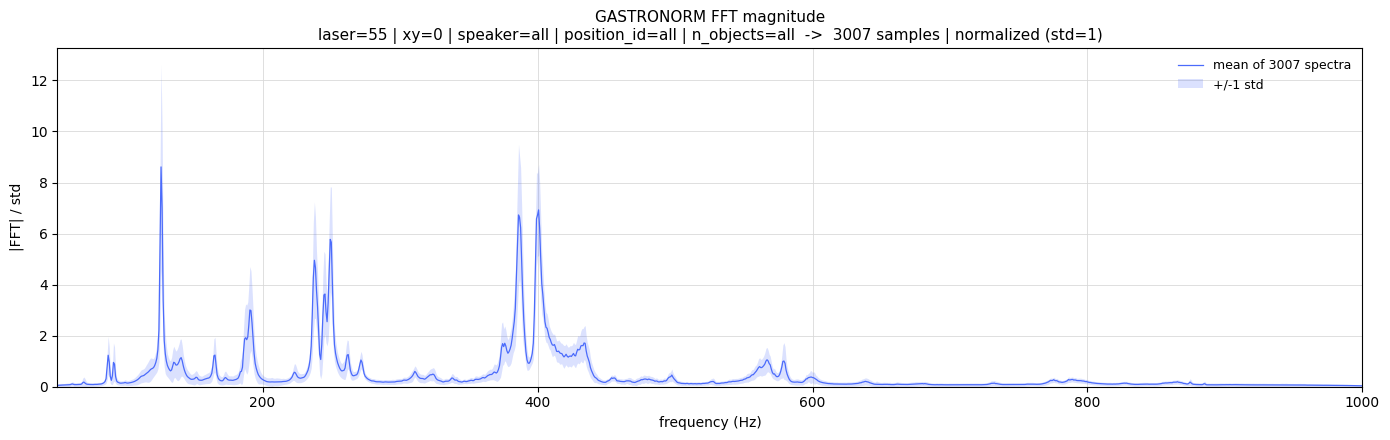

(array([[0.02867716, 0.03058373, 0.02797596, ..., 0.00798497, 0.0077324 ,
         0.00310659],
        [0.03641289, 0.03803757, 0.01019739, ..., 0.01113049, 0.02903457,
         0.01961369],
        [0.00427747, 0.04734576, 0.03182845, ..., 0.02674511, 0.03640709,
         0.07026985],
        ...,
        [0.13678138, 0.10163949, 0.03122593, ..., 0.0631846 , 0.08544127,
         0.08025517],
        [0.08845662, 0.02762328, 0.02852171, ..., 0.03314067, 0.01651681,
         0.02033426],
        [0.02966138, 0.1526239 , 0.06953346, ..., 0.04684772, 0.05133729,
         0.05741578]], dtype=float32),
 array([  50.76923077,   51.53846154,   52.30769231, ...,  998.46153846,
         999.23076923, 1000.        ]))

In [12]:


# one laser / channel, averaged over every speaker and position
plot_fft_magnitude(gastronorm_df, "GASTRONORM", laser=55, xy_channel=0)

# pin the speaker and the object count too
plot_fft_magnitude(gastronorm_df, "GASTRONORM", laser=55, xy_channel=0, speaker=4, n_objects=2)

# empty boxes vs boxes with two objects, on one axis
fig, ax = plt.subplots(figsize=(14, 4.5))
for n, color in ((0, "#4b6bfb"), (2, "#d9730d")):
    rows, sub = filter_df(gastronorm_df, n_objects=n)
    stack, freqs = load_fft_magnitudes(rows, laser=55, xy_channel=0)
    ax.plot(freqs, stack.mean(axis=0), lw=0.9, color=color,
            label=f"n_objects={n} ({len(rows)} samples)")
ax.set_title("GASTRONORM FFT magnitude\nlaser=55 | xy=0 | speaker=all | position_id=all | split by n_objects",
             fontsize=11)
ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("|FFT|")
ax.set_xlim(freqs[0], freqs[-1]); ax.set_ylim(bottom=0)
ax.legend(loc="upper right", fontsize=9, frameon=False)
ax.grid(color="0.85", lw=0.6); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

# same slice, with each spectrum normalized to std 1 before averaging
plot_fft_magnitude(gastronorm_df, "GASTRONORM", laser=55, xy_channel=0, normalize_std=True)

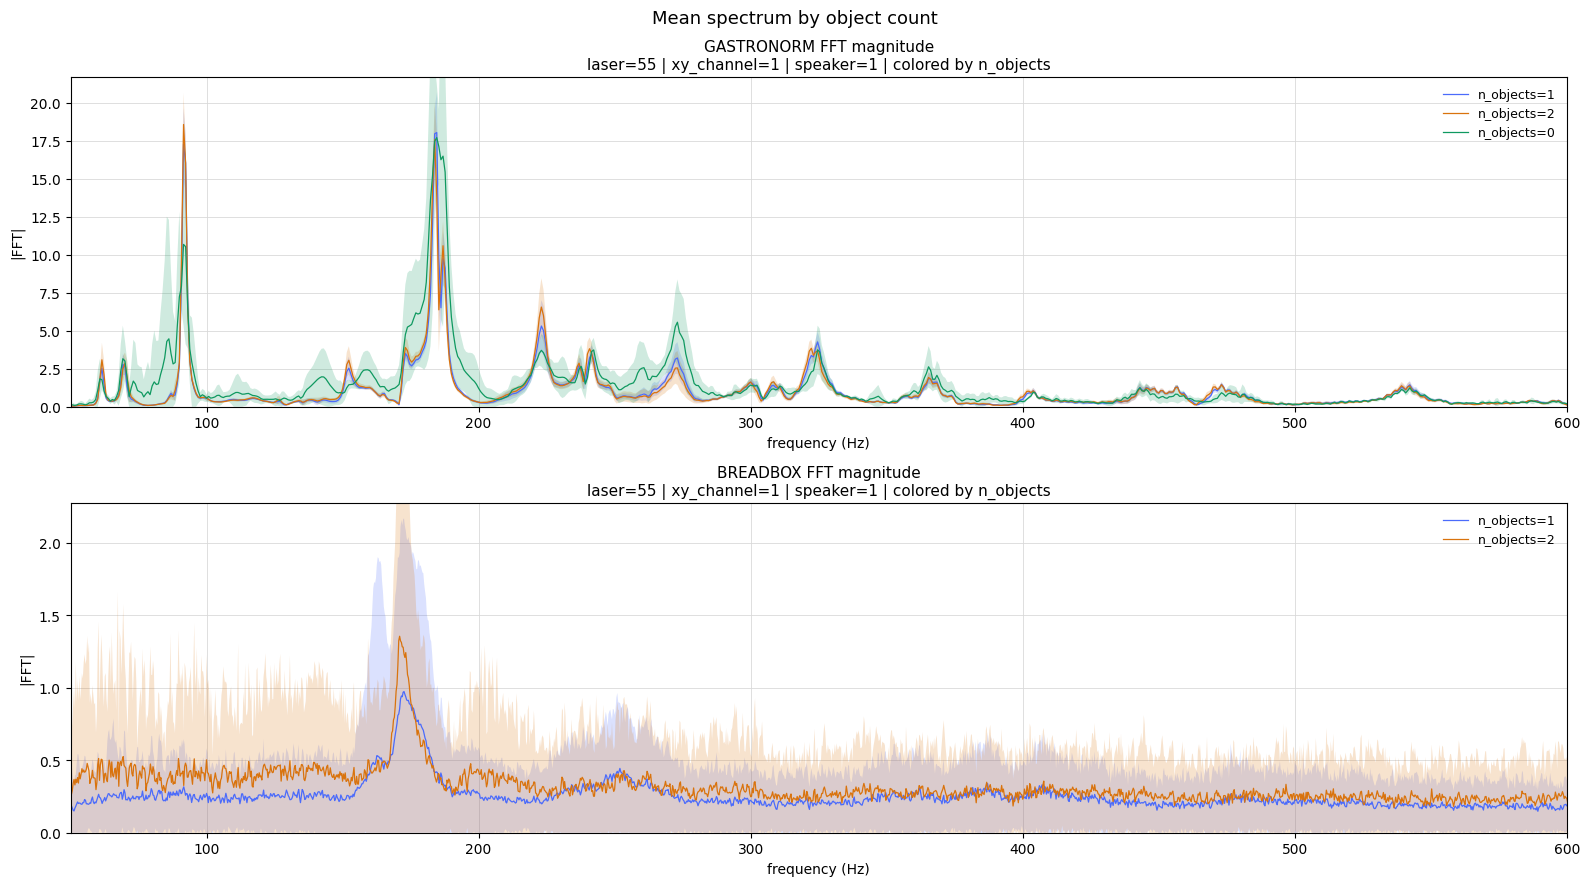

In [13]:
# Both datasets, one panel each: a single laser / xy channel, colored by object count.
# Each dataset gets its own axis -- their freq grids differ (1235 vs 2946 bins).
fig, axes = plt.subplots(2, 1, figsize=(16, 9))

for ax, (label, df) in zip(axes, [("GASTRONORM", gastronorm_df), ("BREADBOX", breadbox_df)]):
    plot_fft_by(df, "n_objects", label, values=[1, 2] + ([0] if label == "GASTRONORM" else []), ax=ax, laser=55, xy_channel=1, speaker=1, xlim=(50, 600), show_std=True, logy=False)

fig.suptitle("Mean spectrum by object count", fontsize=13)
fig.tight_layout()
plt.show()


# 3 Sample-to-sample correlation

Each sample's whole spectrum -- (L lasers, F freqs, C channels) -- is flattened into one
long vector, mean-centered and scaled to unit length. The dot product of two such vectors
*is* their Pearson correlation, so the full matrix is a single `Z @ Z.T`.

Sorting the rows by a metadata key (speaker, n_objects, position_id) puts same-group
samples in contiguous blocks: if the key drives the signal, the diagonal blocks are hot
and the off-diagonal blocks are cold.

In [14]:
def load_sample_vectors(rows, laser=None, xy_channel=None, freq_range=None,
                        fft_name="vibration/04_fft.npz"):
    """One flattened |FFT| vector per sample.

    Each sample's fft is (1, L, F, C); we keep the requested lasers / channels /
    frequency band and flatten what is left into a single vector, so a sample is one
    point in (L*F*C)-space. Returns (vectors, kept_rows, freqs) where vectors is
    (n_samples, L*F*C) and kept_rows is the subset of rows that actually had an fft
    on disk, aligned row-for-row with vectors.

    freq_range=(lo, hi) in Hz trims the band before flattening -- useful for dropping
    the DC end or restricting to where the speaker actually excites the box.
    """
    lasers, channels = _as_list(laser), _as_list(xy_channel)
    vectors, kept, freqs, fsel, n_bins = [], [], None, None, None

    for idx, sample_dir in zip(rows.index, rows["dir"]):
        path = sample_dir / fft_name
        if not path.exists(): continue
        with np.load(path) as z:
            fft, f = z["fft"], z["freqs"]

        if fsel is None:
            fsel = (np.arange(len(f)) if freq_range is None
                    else np.where((f >= freq_range[0]) & (f <= freq_range[1]))[0])
            n_bins, freqs = len(f), f[fsel]
        elif len(f) != n_bins:  # samples must share a freq grid to be comparable
            raise ValueError(f"{sample_dir}: freq grid is {len(f)} bins, expected {n_bins}")

        mag = np.abs(fft[0])                                  # (L, F, C)
        li = np.arange(mag.shape[0]) if lasers is None else np.asarray(lasers)
        ci = np.arange(mag.shape[2]) if channels is None else np.asarray(channels)
        vectors.append(mag[np.ix_(li, fsel, ci)].reshape(-1))
        kept.append(idx)

    if not vectors: return np.empty((0, 0)), rows.iloc[:0], freqs
    return np.stack(vectors), rows.loc[kept], freqs


def pearson_matrix(vectors):
    """Pearson correlation between every pair of flattened samples.

    Mean-centering each vector and dividing by its L2 norm makes the dot product
    exactly Pearson's r, so the whole matrix is one gram product.
    """
    z = vectors - vectors.mean(axis=1, keepdims=True)
    z /= np.linalg.norm(z, axis=1, keepdims=True) + 1e-12
    return np.clip(z @ z.T, -1.0, 1.0)


def sample_correlation(df, sort_by="speaker", speaker=None, position_id=None,
                       n_objects=None, sample_id=None, laser=None, xy_channel=None,
                       freq_range=None, fft_name="vibration/04_fft.npz", verbose=True):
    """Correlation matrix over the samples a filter selects, sorted into blocks.

    speaker / position_id / n_objects / sample_id filter rows through filter_df, so
    they take a scalar, a list, or None ('all'). laser / xy_channel restrict which
    part of each spectrum goes into the vector; None keeps everything.

    sort_by names the metadata column whose value orders the rows -- 'speaker',
    'n_objects', 'position_id'. Samples sharing a value land in one contiguous block,
    which is what makes the block structure readable.

    Returns (corr, sorted_rows, subtitle, bounds) where bounds is the list of
    (value, start, stop) blocks for drawing the group separators.
    """
    rows, subtitle = filter_df(df, sample_id, speaker, position_id, n_objects, verbose=verbose)
    if rows.empty: return np.empty((0, 0)), rows, subtitle, []

    rows = rows.sort_values([sort_by, "sample_id_int"], kind="stable")
    vectors, rows, _ = load_sample_vectors(rows, laser, xy_channel, freq_range, fft_name)
    if vectors.size == 0: return np.empty((0, 0)), rows, subtitle, []

    corr = pearson_matrix(vectors)

    # contiguous runs of sort_by, in the order they now appear
    bounds, values = [], rows[sort_by].to_numpy()
    start = 0
    for i in range(1, len(values) + 1):
        if i == len(values) or values[i] != values[start]:
            bounds.append((values[start], start, i)); start = i

    subtitle = (f"laser={_fmt(laser)} | xy={_fmt(xy_channel)} | {subtitle}"
                f" | sorted by {sort_by}"
                + (f" | {freq_range[0]}-{freq_range[1]} Hz" if freq_range else ""))
    return corr, rows, subtitle, bounds


def plot_sample_correlation(df, label="", sort_by="speaker", ax=None, vmin=0.0,
                            vmax=1.0, cmap="magma", show_blocks=True, title=None,
                            annotate=False, tick_labels=None, **kwargs):
    """Heatmap of sample-to-sample Pearson correlation, blocked by sort_by.

    The color scale is fixed at r in [0, 1] for every call, so GASTRONORM and BREADBOX
    panels are directly comparable by eye -- the two datasets live in very different
    ranges (~0.75-0.97 vs ~0.2-0.5) and a per-panel scale would hide exactly that.
    Negative correlations do not occur here (these are |FFT| magnitudes), so nothing is
    clipped by starting at 0.

    annotate writes the r value in each cell (only readable for a handful of
    samples); tick_labels overrides the per-block tick text. Remaining kwargs go to
    sample_correlation (speaker, n_objects, laser, ...).
    """
    corr, rows, subtitle, bounds = sample_correlation(df, sort_by=sort_by, **kwargs)
    if corr.size == 0:
        print(f"{label}: no samples matched -- {subtitle}"); return

    own_ax = ax is None
    if own_ax: _, ax = plt.subplots(figsize=(8, 7))

    im = ax.imshow(corr, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")

    if show_blocks and len(bounds) > 1:
        for _, start, stop in bounds[:-1]:
            ax.axhline(stop - 0.5, color="0.15", lw=0.8)
            ax.axvline(stop - 0.5, color="0.15", lw=0.8)
        centers = [(start + stop - 1) / 2 for _, start, stop in bounds]
        names = tick_labels if tick_labels is not None else [str(v) for v, _, _ in bounds]
        ax.set_xticks(centers); ax.set_xticklabels(names, fontsize=8)
        ax.set_yticks(centers); ax.set_yticklabels(names, fontsize=8)

    if annotate:
        mid = (vmin + vmax) / 2
        for i in range(corr.shape[0]):
            for j in range(corr.shape[1]):
                ax.text(j, i, f"{corr[i, j]:.3f}", ha="center", va="center", fontsize=9,
                        color="white" if corr[i, j] < mid else "black")

    ax.set_xlabel(sort_by); ax.set_ylabel(sort_by)
    ax.set_title(title if title is not None
                 else f"{label} sample correlation\n{subtitle}", fontsize=10)
    ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson r")

    if own_ax:
        plt.tight_layout()
        plt.show()
    return corr, rows, bounds


def block_means(corr, bounds):
    """Mean correlation of each (group, group) block, as a small labeled dataframe.

    The diagonal excludes each sample's self-correlation (always 1.0), so a diagonal
    entry is the honest 'how alike are two different samples in this group'.
    """
    names = [v for v, _, _ in bounds]
    out = np.zeros((len(bounds), len(bounds)))
    for i, (_, a0, a1) in enumerate(bounds):
        for j, (_, b0, b1) in enumerate(bounds):
            block = corr[a0:a1, b0:b1]
            if i == j:
                n = block.shape[0]
                out[i, j] = ((block.sum() - np.trace(block)) / max(n * (n - 1), 1)) if n > 1 else np.nan
            else:
                out[i, j] = block.mean()
    return pd.DataFrame(out, index=names, columns=names)

## 3.1 Four matched samples, n_objects = 0 / 1 / 2 / 3

Start with the smallest case that can be read by eye: one sample per object count, all
from the same speaker, chosen so their `avg_com` are as close together as possible. With
position held roughly fixed, what is left between the four spectra is mostly the object
count itself.

Empty boxes carry the sentinel `avg_com = [-1, -1]`, so they cannot take part in the
distance -- the tight triple is chosen over n=1/2/3 and an empty sample from the same
speaker is attached to it.

In [15]:
import itertools


def com_matched_samples(df, n_values=(1, 2, 3), empty_n=0, speaker=None, verbose=True):
    """One sample per object count, same speaker, with avg_com as tight as possible.

    Empty boxes store the sentinel avg_com = [-1, -1], so they carry no position and
    are excluded from the distance: the match is computed over n_values, then a sample
    with n_objects == empty_n from the same speaker is appended (empty_n=None skips it).

    Anchors on the rarest count and takes each other count's nearest sample by COM, per
    speaker; the speaker whose resulting group is tightest wins. 'Tightest' is the max
    pairwise COM distance -- worst-case spread, not an average that could hide one
    outlier. Returns (rows, spread_px), rows ordered by n_objects.
    """
    cand = df[df["n_objects"].isin(n_values)].copy()
    cand["com"] = cand["avg_com"].apply(lambda v: np.asarray(v, dtype=float))
    cand = cand[cand["com"].apply(lambda c: c.size == 2 and (c >= 0).all())]

    anchor_n = min(n_values, key=lambda n: (cand["n_objects"] == n).sum())
    other_n = [n for n in n_values if n != anchor_n]
    best = None

    for spk, g in cand.groupby("speaker"):
        if speaker is not None and spk != speaker: continue
        pools = {n: g[g["n_objects"] == n] for n in n_values}
        if any(p.empty for p in pools.values()): continue

        for anchor in pools[anchor_n].itertuples():
            idx, coms = [anchor.Index], [anchor.com]
            for n in other_n:
                pool = pools[n]
                d = pool["com"].apply(lambda c: np.linalg.norm(c - anchor.com))
                idx.append(d.idxmin())
                coms.append(pool.at[d.idxmin(), "com"])
            spread = max(np.linalg.norm(a - b) for a, b in itertools.combinations(coms, 2))
            if best is None or spread < best[0]: best = (spread, spk, idx)

    if best is None:
        raise ValueError("no speaker has a sample for every requested n_objects")
    spread, spk, idx = best
    rows = df.loc[idx]

    if empty_n is not None:
        empties = df[(df["n_objects"] == empty_n) & (df["speaker"] == spk)]
        if empties.empty:
            if verbose: print(f"  (no n_objects={empty_n} sample for speaker {spk})")
        else:
            rows = pd.concat([empties.iloc[[0]], rows])

    rows = rows.sort_values("n_objects")
    if verbose:
        print(f"speaker {spk} | COM spread {spread:.1f} px (over n_objects={list(n_values)})")
        for r in rows.itertuples():
            com = np.asarray(r.avg_com, dtype=float)
            tag = "  (empty box, no COM)" if (com < 0).any() else ""
            print(f"  n={r.n_objects}  sample {r.sample_id}  pos={r.position_id}  "
                  f"com=({com[0]:7.1f}, {com[1]:7.1f}){tag}")
    return rows, spread


quartet, spread = com_matched_samples(gastronorm_df)
quartet[["sample_id", "speaker", "position_id", "n_objects", "layout", "avg_com"]]

speaker 1 | COM spread 11.5 px (over n_objects=[1, 2, 3])
  n=0  sample 000017  pos=3  com=(   -1.0,    -1.0)  (empty box, no COM)
  n=1  sample 002809  pos=352  com=(  559.4,   653.7)
  n=2  sample 003009  pos=377  com=(  552.5,   662.8)
  n=3  sample 002769  pos=347  com=(  554.4,   662.2)


,sample_id,speaker,position_id,n_objects,layout,avg_com
7,000017,1,3,0,empty-box,"[-1.0, -1.0]"
2799,002809,1,352,1,red-cube,"[559.39604357, 653.6912542]"
2999,003009,1,377,2,y-shift,"[552.48630389, 662.82215262]"
2759,002769,1,347,3,purple--green-red-cube,"[554.38081956, 662.18435056]"


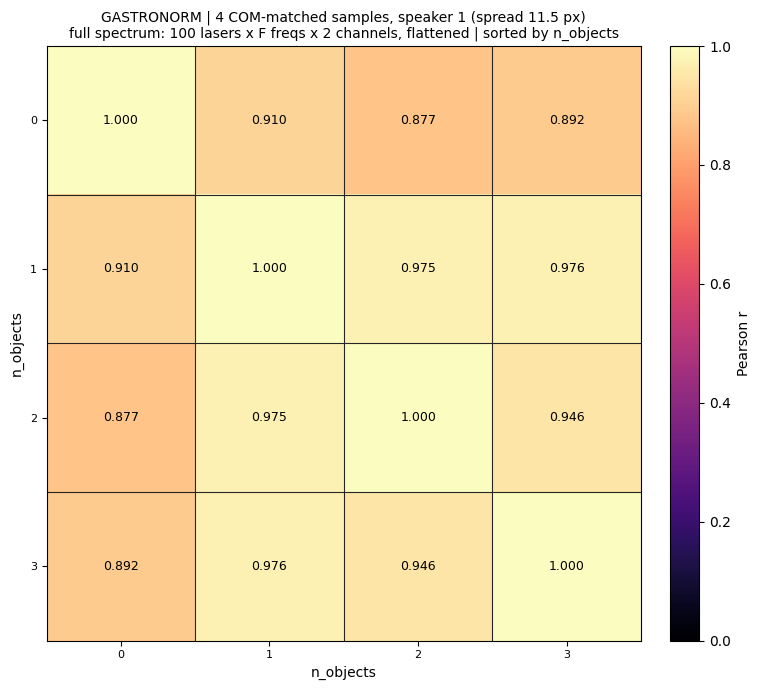

,n=0,n=1,n=2,n=3
n=0,1.0000,0.9103,0.8769,0.8920
n=1,0.9103,1.0000,0.9750,0.9757
n=2,0.8769,0.9750,1.0000,0.9460
n=3,0.8920,0.9757,0.9460,1.0000


In [16]:
# The 4x4 matrix for those matched samples. Every pair is highly correlated (the box's
# own resonances dominate any spectrum), so the annotated numbers carry the signal here
# rather than the color -- the shared r in [0, 1] scale makes the whole panel look hot.
corr, rows, bounds = plot_sample_correlation(
    gastronorm_df, "GASTRONORM", sort_by="n_objects",
    sample_id=quartet["sample_id"].tolist(), annotate=True,
    title=(f"GASTRONORM | 4 COM-matched samples, speaker {quartet['speaker'].iloc[0]}"
           f" (spread {spread:.1f} px)\nfull spectrum: 100 lasers x F freqs x 2 channels,"
           " flattened | sorted by n_objects"),
)

pd.DataFrame(np.round(corr, 4),
             index=[f"n={n}" for n in rows["n_objects"]],
             columns=[f"n={n}" for n in rows["n_objects"]])

## 3.2 Many samples, blocked by n_objects and by speaker

The same matrix over many samples at once. Rows are sorted so samples sharing the key sit
in one contiguous block: if that key drives the signal, the diagonal blocks are hotter
than the off-diagonal ones. `block_means` collapses each block to its mean r, with the
diagonal excluding the trivial self-correlation of 1.0.

One factor varies at a time -- speaker is pinned in the n_objects view, and object count
is pinned in the speaker view.

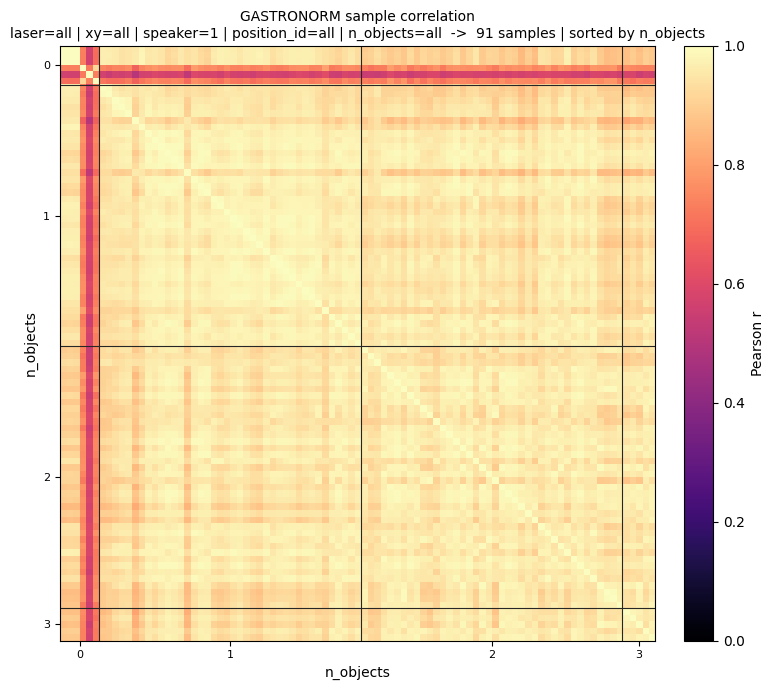


mean r per (n_objects, n_objects) block -- 91 samples


,0,1,2,3
0,0.7570,0.8173,0.7991,0.7816
1,0.8173,0.9638,0.9478,0.9316
2,0.7991,0.9478,0.9561,0.9524
3,0.7816,0.9316,0.9524,0.9624


In [17]:
def cap_per_group(df, key, n_per_group=40, seed=0):
    """At most n_per_group samples per distinct value of key.

    The counts are wildly unbalanced (n_objects=2 has ~2300 samples, n_objects=3 has
    40), and an uncapped matrix is mostly one group correlating with itself. Sampling
    is seeded so the figure is reproducible.

    Selects by index rather than groupby-apply, which in pandas 2.x would drop the
    grouping column out of the frame and take the sort key with it.
    """
    idx = []
    for _, g in df.groupby(key):
        idx.extend(g.sample(min(len(g), n_per_group), random_state=seed).index)
    return df.loc[idx].sort_values("sample_id_int")


# --- sorted by n_objects, speaker pinned ------------------------------------------
sub = cap_per_group(gastronorm_df[gastronorm_df["speaker"] == 1], "n_objects", 40)
corr_n, rows_n, bounds_n = plot_sample_correlation(
    sub, "GASTRONORM", sort_by="n_objects", speaker=1,
)
print(f"\nmean r per (n_objects, n_objects) block -- {len(rows_n)} samples")
block_means(corr_n, bounds_n).round(4)

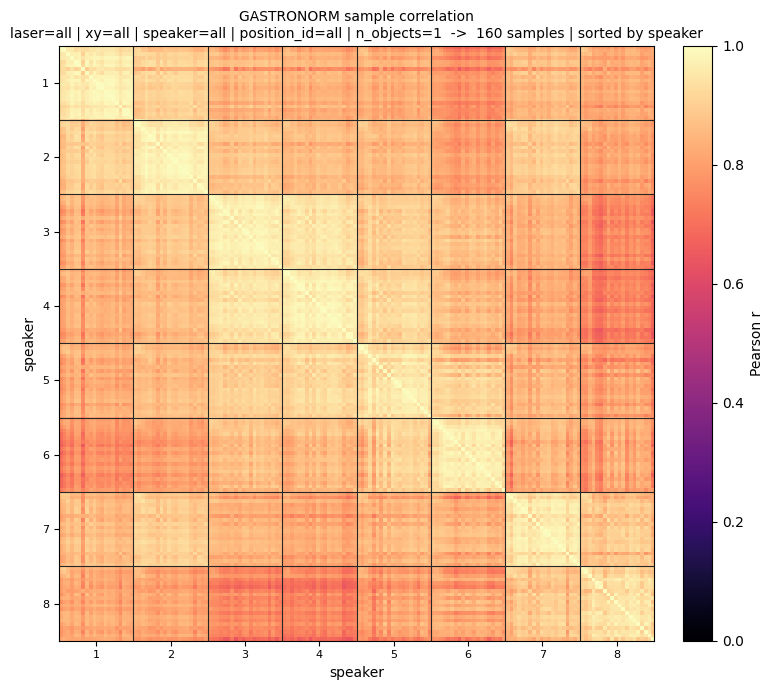


mean r per (speaker, speaker) block -- 160 samples


,1,2,3,4,5,6,7,8
1,0.9618,0.9001,0.8400,0.8305,0.8256,0.7642,0.8552,0.8190
2,0.9001,0.9672,0.8786,0.8593,0.8593,0.8016,0.8971,0.8114
3,0.8400,0.8786,0.9664,0.9443,0.8965,0.8666,0.8402,0.7460
4,0.8305,0.8593,0.9443,0.9660,0.9161,0.8545,0.8132,0.7351
5,0.8256,0.8593,0.8965,0.9161,0.9422,0.8910,0.8426,0.7958
6,0.7642,0.8016,0.8666,0.8545,0.8910,0.9558,0.8336,0.8062
7,0.8552,0.8971,0.8402,0.8132,0.8426,0.8336,0.9526,0.8812
8,0.8190,0.8114,0.7460,0.7351,0.7958,0.8062,0.8812,0.9306


In [19]:
# --- sorted by speaker, object count pinned ---------------------------------------
# Speaker is the one factor we know changes the excitation itself, so this is the
# reference for "what a real block structure looks like" in these matrices.
sub = cap_per_group(gastronorm_df[gastronorm_df["n_objects"] == 1], "speaker", 20)
corr_s, rows_s, bounds_s = plot_sample_correlation(
    sub, "GASTRONORM", sort_by="speaker", n_objects=1,
)
print(f"\nmean r per (speaker, speaker) block -- {len(rows_s)} samples")
block_means(corr_s, bounds_s).round(4)

# 4 The same correlations for BREADBOX

Same machinery, different dataset. Two constraints on what is usable here:

* **n_objects = 0 is unusable** -- the empty-box samples were recorded incorrectly.
* **n_objects = 3 does not exist** -- breadbox only has 1- and 2-object layouts.

So everything below runs on `n_objects` in {1, 2}: 600 and 400 samples, evenly split as
75 / 50 per speaker across all 8 speakers. No COM matching is used -- samples are drawn
as they come, so position varies freely within every group.

Breadbox has its own frequency grid (2946 bins vs the gastronorm's 1235), so its vectors
are 100 x 2946 x 2. All heatmaps share the r in [0, 1] color scale, so a breadbox panel
can be compared against a gastronorm one directly.

## 4.1 A few individual samples, n_objects = 1 vs 2

No COM matching here -- samples are taken as they come (seeded, so the pick is stable),
a few per object count from one speaker. Position therefore varies freely within each
group, which is the point: this is what the correlation looks like without hand-picking
the comparison.

,sample_id,speaker,n_objects,layout,avg_com
200,000201,1,1,purple-cube,"[153.5873896398156, 510.28049066333307]"
440,000441,1,1,purple-cube,"[154.62453856615505, 491.17476199728]"
560,000561,1,2,purple-cube-green-cube,"[171.83996472441106, 373.53777434730284]"
568,000569,1,2,purple-cube-green-cube,"[142.40265383172746, 204.97282249513967]"
704,000705,1,2,purple-cube-green-cube,"[102.13948793881013, 323.14979486783176]"
880,000881,1,1,green-cube,"[101.13753925734343, 125.34426380934786]"


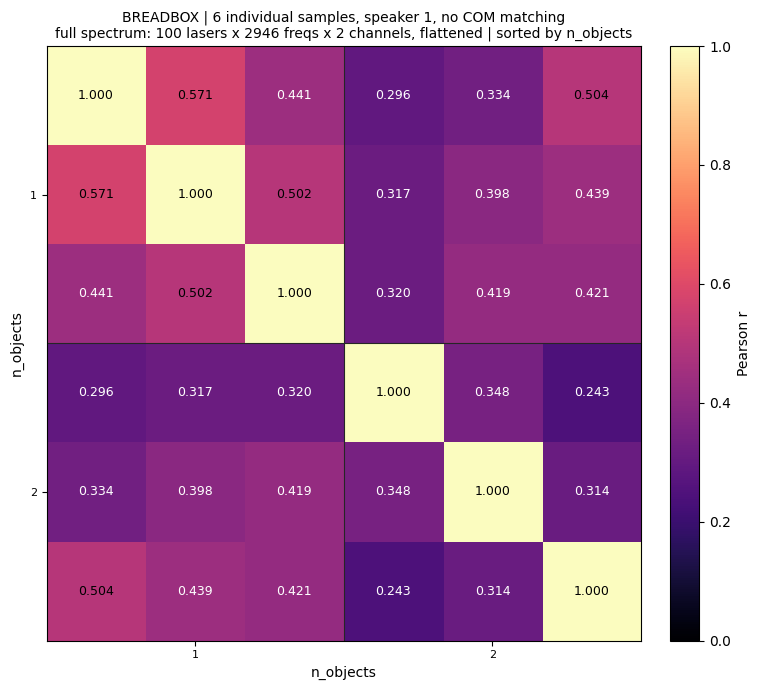

In [20]:
# n=0 is miscorded and n=3 does not exist, so the usable slice is {1, 2}.
BREADBOX_NS = (1, 2)

# Three samples per count from one speaker, taken as they come.
few = cap_per_group(
    breadbox_df[(breadbox_df["speaker"] == 1) & breadbox_df["n_objects"].isin(BREADBOX_NS)],
    "n_objects", 3)
display(few[["sample_id", "speaker", "n_objects", "layout", "avg_com"]])

corr_p, rows_p, bounds_p = plot_sample_correlation(
    few, "BREADBOX", sort_by="n_objects", speaker=1, annotate=True,
    title=("BREADBOX | 6 individual samples, speaker 1, no COM matching\n"
           "full spectrum: 100 lasers x 2946 freqs x 2 channels, flattened"
           " | sorted by n_objects"),
)

In [21]:
# Does object count separate anything on its own? Per speaker, compare the mean
# within-count correlation against the mean across-count one, over all pairs in a random
# sample of rows -- no COM matching, so position varies freely on both sides and the only
# systematic difference between the two numbers is the object count.
rows_out = []
for spk in sorted(breadbox_df["speaker"].dropna().unique()):
    g = cap_per_group(
        breadbox_df[(breadbox_df["speaker"] == spk)
                    & breadbox_df["n_objects"].isin(BREADBOX_NS)], "n_objects", 15)
    corr, kept, _, _ = sample_correlation(g, sort_by="n_objects", speaker=spk, verbose=False)

    n_vals = kept["n_objects"].to_numpy()
    same = n_vals[:, None] == n_vals[None, :]
    off_diag = ~np.eye(len(n_vals), dtype=bool)

    rows_out.append({"speaker": spk, "n_samples": len(n_vals),
                     "within-count r": round(float(corr[same & off_diag].mean()), 4),
                     "across-count r": round(float(corr[~same].mean()), 4)})

within_across = pd.DataFrame(rows_out).set_index("speaker")
within_across["gap"] = (within_across["within-count r"]
                        - within_across["across-count r"]).round(4)
print("BREADBOX: within- vs across-count correlation, per speaker (no COM matching)\n")
display(within_across)
print(within_across[["within-count r", "across-count r", "gap"]].mean().round(4).to_string())

BREADBOX: within- vs across-count correlation, per speaker (no COM matching)



,n_samples,within-count r,across-count r,gap
speaker,,,,
1,30,0.4586,0.4367,0.0219
2,30,0.5412,0.5219,0.0193
3,30,0.4402,0.4180,0.0222
4,30,0.4680,0.4495,0.0185
5,30,0.2494,0.2347,0.0147
6,30,0.2361,0.2196,0.0165
7,30,0.3058,0.2897,0.0161
8,30,0.2752,0.2639,0.0113


within-count r    0.3718
across-count r    0.3542
gap               0.0176


## 4.2 Many samples, blocked by n_objects and by speaker

The section 3.2 pair of views, restricted to `n_objects` in {1, 2}. The n=0 block that
appeared in the gastronorm matrices is deliberately absent here.

Note that the two views are not equally informative in breadbox: with only two usable
object counts the n_objects matrix has a single off-diagonal block, while the speaker
matrix still has all 8 groups.

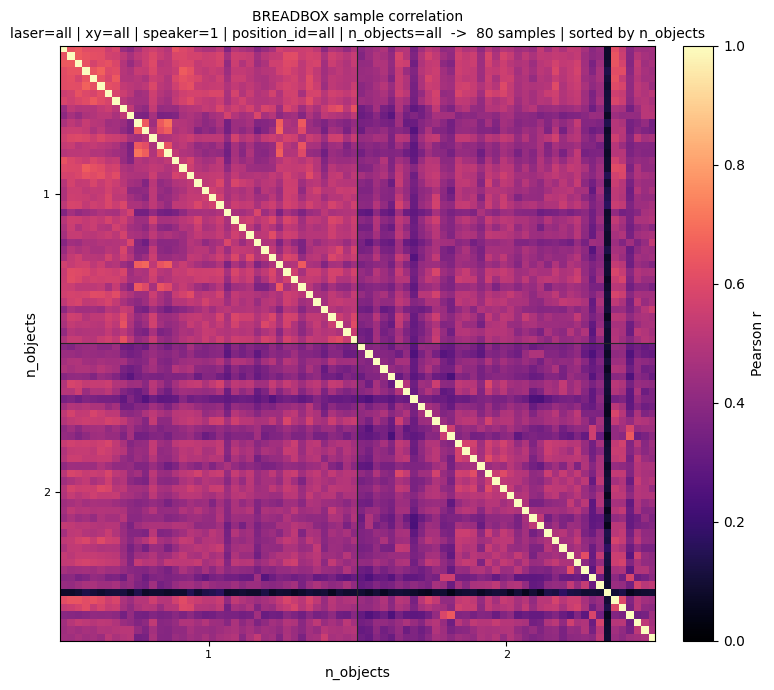


mean r per (n_objects, n_objects) block -- 80 samples


,1,2
1,0.5066,0.4353
2,0.4353,0.4038


In [22]:
bb = breadbox_df[breadbox_df["n_objects"].isin(BREADBOX_NS)]

# --- sorted by n_objects, speaker pinned ------------------------------------------
sub = cap_per_group(bb[bb["speaker"] == 1], "n_objects", 40)
corr_bn, rows_bn, bounds_bn = plot_sample_correlation(
    sub, "BREADBOX", sort_by="n_objects", speaker=1,
)
print(f"\nmean r per (n_objects, n_objects) block -- {len(rows_bn)} samples")
block_means(corr_bn, bounds_bn).round(4)

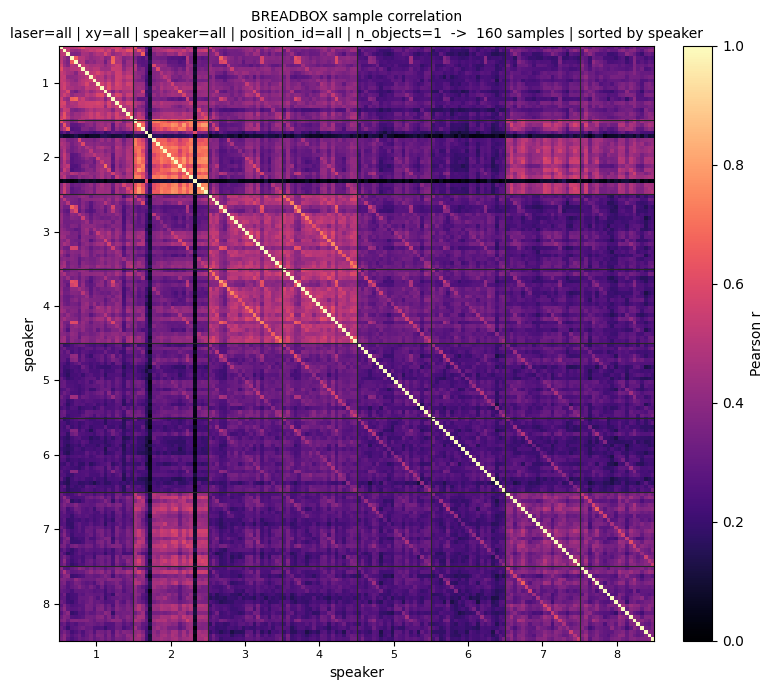


mean r per (speaker, speaker) block -- 160 samples


,1,2,3,4,5,6,7,8
1,0.4951,0.3716,0.3795,0.3765,0.2667,0.2320,0.2858,0.3165
2,0.3716,0.5459,0.3218,0.3147,0.2676,0.2142,0.4185,0.3716
3,0.3795,0.3218,0.4618,0.4767,0.3140,0.2875,0.2636,0.2478
4,0.3765,0.3147,0.4767,0.4840,0.3305,0.3063,0.2731,0.2546
5,0.2667,0.2676,0.3140,0.3305,0.2675,0.2601,0.2720,0.2560
6,0.2320,0.2142,0.2875,0.3063,0.2601,0.2471,0.2436,0.2261
7,0.2858,0.4185,0.2636,0.2731,0.2720,0.2436,0.3795,0.3512
8,0.3165,0.3716,0.2478,0.2546,0.2560,0.2261,0.3512,0.3350


In [23]:
# --- sorted by speaker, object count pinned ---------------------------------------
sub = cap_per_group(bb[bb["n_objects"] == 1], "speaker", 20)
corr_bs, rows_bs, bounds_bs = plot_sample_correlation(
    sub, "BREADBOX", sort_by="speaker", n_objects=1,
)
print(f"\nmean r per (speaker, speaker) block -- {len(rows_bs)} samples")
block_means(corr_bs, bounds_bs).round(4)